#This dataset contains california housing prices (1990 census)

#This project will analyze the housing dataset to understand factors that most influence price.

In [15]:
import pandas as pd
df = pd.read_csv("housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [16]:
df.info()
df["ocean_proximity"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.groupby("ocean_proximity")["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240267.990812
INLAND        124896.863147
ISLAND        380440.000000
NEAR BAY      259279.292070
NEAR OCEAN    249042.355023
Name: median_house_value, dtype: float64

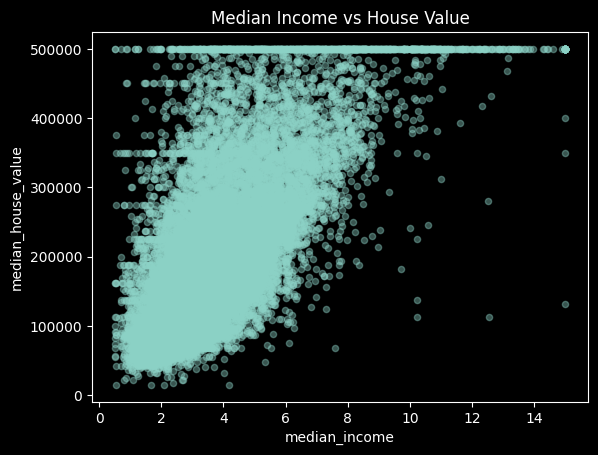

In [19]:
import matplotlib.pyplot as plt
df.plot.scatter(x="median_income", y="median_house_value", alpha = .4)
plt.title("Median Income vs House Value")
plt.show()

In [20]:
df["householdrooms"] = df["total_rooms"] / df["population"]
#1

In [21]:
encoding = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
encoding = encoding.dropna()


In [22]:
from sklearn.linear_model import LinearRegression
x = encoding.drop("median_house_value", axis=1)
y = encoding["median_house_value"]
model = LinearRegression()
model.fit(x, y)
model.score(x, y)


0.6529436804604412

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(xtrain, ytrain)
print(model.score(xtrain, ytrain))
print(model.score(xtest, ytest))

0.9757155112570001
0.8326884514571921


#median income is strongest prediction,
#proximity to ocean matters,
#relationships aren't just linear,
#random forest performs better than linear regression